Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

Load the best model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/resnet50.keras"
)

print("ResNet50 loaded successfully.")

ResNet50 loaded successfully.


Check the Model Layers

In [4]:
for layer in model.layers:
    print(layer.name, layer.output.shape)

input_layer_2 (None, 224, 224, 3)
resnet50 (None, 7, 7, 2048)
global_average_pooling2d_1 (None, 2048)
dense_2 (None, 128)
dropout_1 (None, 128)
dense_3 (None, 6)


In [5]:
last_conv_layer_name = "conv5_block3_out"

Load one text image

In [6]:
img_path = (
    "/content/drive/MyDrive/ML_Projects/"
    "AI_industrial_defect_detection/NEU-DET/"
    "validation/images/"
)

In [7]:
import os

class_name = "scratches"

class_path = os.path.join(img_path, class_name)

image_name = os.listdir(class_path)[0]

image_path = os.path.join(
    class_path,
    image_name
)

print(image_path)

/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/validation/images/scratches/scratches_251.jpg


preprocess the image

In [8]:
img = image.load_img(
    image_path,
    target_size=(224, 224),
    color_mode="rgb"
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = preprocess_input(img_array)

In [9]:
print(img_array.shape)#it has one image in the batch

(1, 224, 224, 3)


Get prediction

In [10]:
predictions = model.predict(
    img_array,
    verbose=0
)

predicted_class = np.argmax(
    predictions[0]
)

confidence = predictions[0][predicted_class]

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

Predicted class: 5
Confidence: 0.9999999


In [11]:
class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

In [12]:
print(
    "Predicted defect:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    f"{confidence:.2%}"
)

Predicted defect: scratches
Confidence: 100.00%


Create a Grad cam function

In [13]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):

    base_model = model.layers[1]

    last_conv_layer = base_model.get_layer(
        last_conv_layer_name
    )

    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array,
            training=False
        )

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

Generate heatmap

In [14]:
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    predicted_class
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


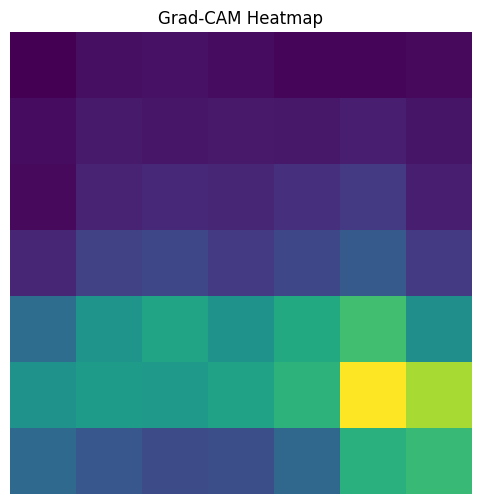

In [15]:
plt.figure(figsize=(6, 6))

plt.imshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.show()

Overlay Heatmap on Original Image

In [16]:
original_img = image.load_img(
    image_path,
    target_size=(224, 224)
)

original_img = image.img_to_array(
    original_img
) / 255.0

In [17]:
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (224, 224)
).numpy()

heatmap_resized = np.squeeze(
    heatmap_resized
)

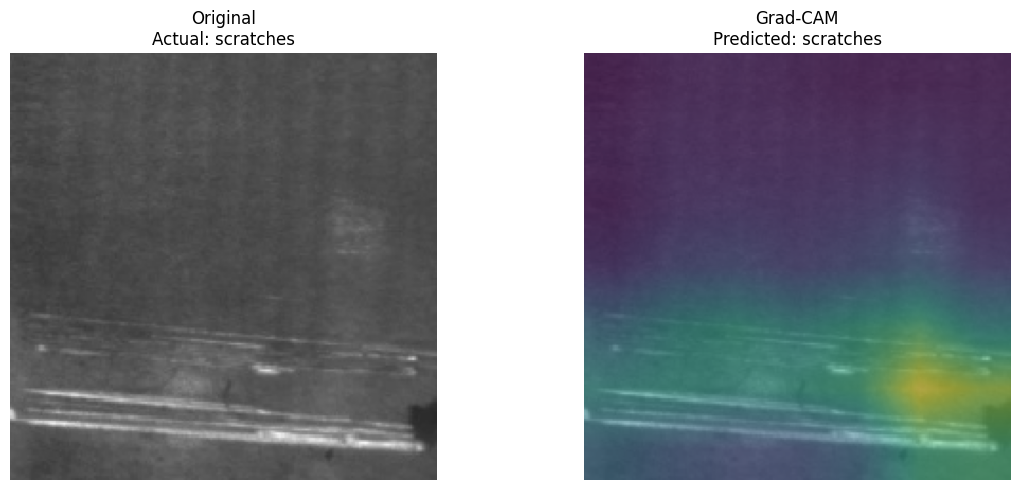

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(original_img)

plt.title(
    f"Original\nActual: {class_name}"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(original_img)

plt.imshow(
    heatmap_resized,
    alpha=0.5
)

plt.title(
    f"Grad-CAM\nPredicted: {class_names[predicted_class]}"
)

plt.axis("off")

plt.tight_layout()

plt.show()